## Lab # 05: Random Forest Classifier

### **Student Information**
- **Name**: Abdul Hayy Khan
- **Roll No**: 24F-AI-051

### Lab Tasks:
1.	Load a dataset for classification (e.g., Titanic, Breast Cancer dataset).

In [22]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [23]:
# loading dataset and preparing features and target
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')
print(f"Dataset Shape: {X.shape}")
print(f"Target distribution (0: Malignant, 1: Benign):\n{y.value_counts()}\n")


Dataset Shape: (569, 30)
Target distribution (0: Malignant, 1: Benign):
target
1    357
0    212
Name: count, dtype: int64



2.	Apply data preprocessing (handle missing values, encode categorical data).

In [35]:
# handling missing values
missing_vals = X.isnull().sum().sum()
print(f"Total missing values found: {missing_vals}")

Total missing values found: 0


3.	Split the dataset into training and testing sets.

In [25]:
# splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}\n")

Training set shape: (398, 30)
Testing set shape: (171, 30)



4.	Train a Random Forest Classifier on the training data.

In [26]:
# training a random forest classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


5.	Make predictions on the test set.


In [27]:
# making predictions
rf_preds = rf_clf.predict(X_test)

6.	Evaluate performance using accuracy, precision, recall, and F1-score.


In [28]:
rf_accuracy = accuracy_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds)
rf_recall = recall_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-Score:  {rf_f1:.4f}\n")

Accuracy:  0.9357
Precision: 0.9444
Recall:    0.9533
F1-Score:  0.9488



7.	Visualize the Confusion Matrix


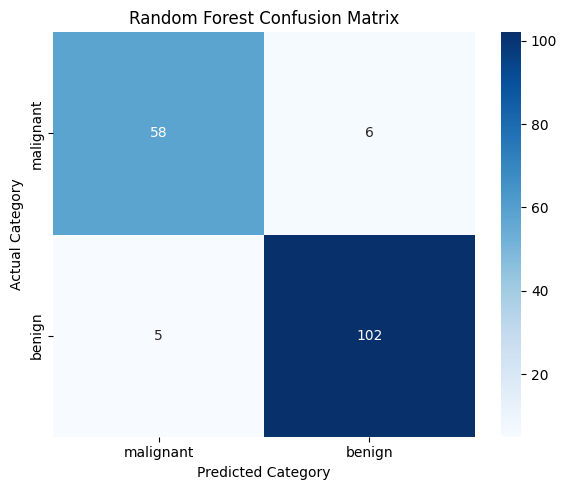

In [29]:
# confusion matrix
rf_cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.tight_layout()
plt.show()


8.	Compare with a Single Decision Tree

In [30]:
# comparing with a single decision tree classifier
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
dt_preds = dt_clf.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_preds)
dt_precision = precision_score(y_test, dt_preds)
dt_recall = recall_score(y_test, dt_preds)
dt_f1 = f1_score(y_test, dt_preds)
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Single Decision Tree': [dt_accuracy, dt_precision, dt_recall, dt_f1],
    'Random Forest': [rf_accuracy, rf_precision, rf_recall, rf_f1]
})
print(comparison_df.to_string(index=False))

   Metric  Single Decision Tree  Random Forest
 Accuracy              0.918129       0.935673
Precision              0.934579       0.944444
   Recall              0.934579       0.953271
 F1-Score              0.934579       0.948837
